# Healthcare Patient Risk Stratification Pipeline

**Pipeline:**
1. Load & clean patient data
2. Preprocess (impute, encode, scale)
3. Select clinical features
4. K-Means clustering → pseudo risk labels (elbow + silhouette to pick *k*)
5. Map cluster IDs to risk levels (Low / Moderate / High / Critical)
6. Train an MLP classifier on the pseudo labels
7. Evaluate (accuracy, confusion matrix, silhouette) and visualize

**To use your own data:** set `CSV_PATH` in the cell below to your file's path. Leave it as `None` to run on generated synthetic demo data.

Expected CSV columns (case-insensitive): `age, bmi, blood_pressure, glucose, cholesterol, heart_rate, smoking, exercise, family_history`


In [41]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

FEATURES = [
    "age", "bmi", "blood_pressure", "glucose",
    "cholesterol", "heart_rate", "smoking", "exercise", "family_history",
]
RISK_ORDER = ["Low Risk", "Moderate Risk", "High Risk", "Critical Risk"]


## 1. Load Data
Set `CSV_PATH` below to your file, or leave as `None` to use synthetic demo data.

In [42]:
CSV_PATH = None  # e.g. "patients.csv"

def load_data(csv_path):
    if csv_path:
        df = pd.read_csv(csv_path)
        df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
        missing = [f for f in FEATURES if f not in df.columns]
        if missing:
            raise ValueError(f"CSV is missing required columns: {missing}")
        return df[FEATURES].copy()

    # Synthetic demo dataset
    rng = np.random.default_rng(RANDOM_STATE)
    n = 600
    df = pd.DataFrame({
        "age": rng.normal(50, 15, n).clip(18, 90),
        "bmi": rng.normal(27, 5, n).clip(15, 50),
        "blood_pressure": rng.normal(125, 18, n).clip(80, 200),
        "glucose": rng.normal(110, 30, n).clip(60, 300),
        "cholesterol": rng.normal(200, 40, n).clip(100, 400),
        "heart_rate": rng.normal(75, 12, n).clip(45, 150),
        "smoking": rng.choice([0, 1], n, p=[0.7, 0.3]),
        "exercise": rng.choice([0, 1], n, p=[0.4, 0.6]),
        "family_history": rng.choice([0, 1], n, p=[0.65, 0.35]),
    })
    for col in ["bmi", "cholesterol", "glucose"]:
        idx = rng.choice(n, size=int(0.03 * n), replace=False)
        df.loc[idx, col] = np.nan
    return df

df_raw = load_data(CSV_PATH)
df_raw.head()


,age,bmi,blood_pressure,glucose,cholesterol,heart_rate,smoking,exercise,family_history
0,54.570756,29.577052,101.194260,108.808812,182.157225,89.988272,0,0,1
1,34.400238,24.112306,116.248506,123.273638,239.207635,83.252306,0,1,0
2,61.256768,33.372236,132.564081,100.867197,211.246927,98.593530,1,0,1
3,64.108471,23.862062,123.156859,97.710532,172.097712,56.426006,0,1,0
4,20.734472,23.816924,113.289855,112.770621,165.362405,71.815679,0,1,1


## 2. Clean & Encode

In [43]:
def clean_and_encode(df):
    df = df.copy()
    binary_cols = ["smoking", "exercise", "family_history"]
    for col in binary_cols:
        if df[col].dtype == object:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str).str.lower())

    numeric_cols = ["age", "bmi", "blood_pressure", "glucose", "cholesterol", "heart_rate"]
    imputer = SimpleImputer(strategy="median")
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[binary_cols] = cat_imputer.fit_transform(df[binary_cols])
    return df

df_clean = clean_and_encode(df_raw)
df_clean.describe()


,age,bmi,blood_pressure,glucose,cholesterol,heart_rate,smoking,exercise,family_history
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,49.654155,26.906162,123.607360,109.458345,201.566542,75.419337,0.290000,0.576667,0.320000
std,14.428981,4.869980,18.635276,28.117323,39.881950,11.541349,0.454141,0.494500,0.466865
min,18.000000,15.000000,80.000000,60.000000,100.000000,45.000000,0.000000,0.000000,0.000000
25%,39.532993,23.882238,111.920049,88.918362,174.694115,67.386765,0.000000,0.000000,0.000000
50%,49.680020,27.049878,123.754547,111.147485,200.250598,75.590072,0.000000,1.000000,0.000000
75%,58.810900,29.977008,135.864118,128.088633,230.028285,83.448580,1.000000,1.000000,1.000000
max,90.000000,42.894268,177.456404,195.723153,322.381249,112.062146,1.000000,1.000000,1.000000


## 3. Feature Scaling

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURES])
X_scaled[:5]


array([[ 0.34102921,  0.54889728, -1.20372788, -0.0231201 , -0.48707528,
         1.26337841, -0.63910148, -1.16713526,  1.45773797],
       [-1.05805419, -0.57416816, -0.39521789,  0.4917545 ,  0.94460026,
         0.67925375, -0.63910148,  0.85679872, -0.68599434],
       [ 0.80478964,  1.3288493 ,  0.48103359, -0.30580137,  0.24292849,
         2.0096029 ,  1.56469673, -1.16713526,  1.45773797],
       [ 1.00259171, -0.62559589, -0.0241948 , -0.41816267, -0.73951796,
        -1.64705001, -0.63910148,  0.85679872, -0.68599434],
       [-2.00594988, -0.6348724 , -0.5541165 ,  0.11790026, -0.90853996,
        -0.31249947, -0.63910148,  0.85679872,  1.45773797]])

## 4. K-Means: Choose *k* via Elbow Method + Silhouette Score

Best K: 2


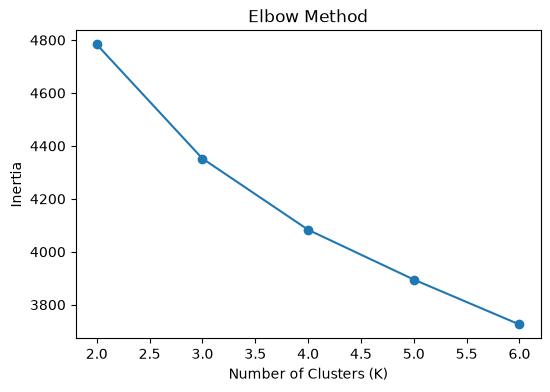

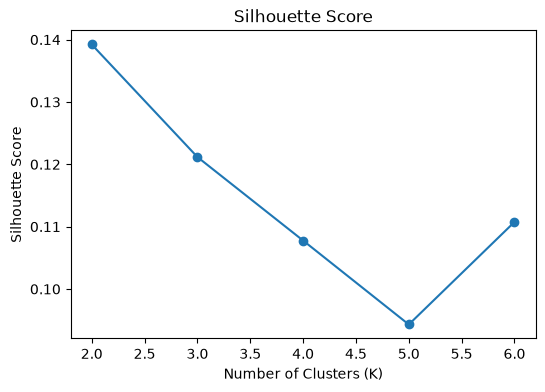

In [45]:
# Try different values of k
k_values = []
inertias = []   #=SSD    cal distance and must be small
silhouette_scores = []    #from -1 to 1   1 is the best


for k in range(2,7):
    model = KMeans(n_clusters=k , random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    k_values . append(k)
    inertias.append(model.inertia_)   #k=2 → 450  k=3 → 320  k=4 → 250
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Find the best k
best_k = k_values[np.argmax(silhouette_scores)]

print("Best K:", best_k)

# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

#Plot Silhouette Score
plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

## 5. Fit K-Means & Map Clusters to Risk Levels
If you want to force a specific number of clusters (e.g. all 4 risk tiers), change `N_CLUSTERS` below instead of using `best_k`.

In [46]:
N_CLUSTERS = best_k  # override e.g. N_CLUSTERS = 4

km_model = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
cluster_ids = km_model.fit_predict(X_scaled)
overall_sil = silhouette_score(X_scaled, cluster_ids)
print(f"Silhouette score at k={N_CLUSTERS}: {overall_sil:.3f}")

def map_clusters_to_risk(df, cluster_ids):
    temp = df.copy()
    temp["cluster"] = cluster_ids
    severity = (
        temp.groupby("cluster")[["glucose", "blood_pressure", "cholesterol", "bmi"]].mean().sum(axis=1)
        + temp.groupby("cluster")["smoking"].mean() * 20
        + temp.groupby("cluster")["family_history"].mean() * 10
        - temp.groupby("cluster")["exercise"].mean() * 15
    )
    ordered_clusters = severity.sort_values().index.tolist()
    n = len(ordered_clusters)
    labels = RISK_ORDER[:n] if n <= 4 else [f"Risk Level {i}" for i in range(n)]
    return {c: l for c, l in zip(ordered_clusters, labels)}

cluster_to_risk = map_clusters_to_risk(df_clean, cluster_ids)
risk_labels_arr = np.array([cluster_to_risk[c] for c in cluster_ids])
print("Cluster to risk mapping:", cluster_to_risk)


Silhouette score at k=2: 0.139
Cluster to risk mapping: {0: 'Low Risk', 1: 'Moderate Risk'}


In [54]:
# Create K-Means model using the best K
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Train the model and assign each patient to a cluster
cluster_ids = model.fit_predict(X_scaled)

# Calculate Silhouette Score
score = silhouette_score(X_scaled, cluster_ids)

print("Silhouette Score:", score)


# Assign a risk level to each cluster
cluster_to_risk = {
    0: "Low Risk",
    1: "Moderate Risk"
}

# Convert cluster numbers into risk labels
risk_labels = []

for cluster in cluster_ids:
    risk_labels.append(cluster_to_risk[cluster])

print("Cluster IDs:", cluster_ids)
print("Risk Labels:", risk_labels)

Silhouette Score: 0.13922140698186786
Cluster IDs: [0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0
 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1
 1 0 1 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1
 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 0 0 1 0 0 1 1 1 0 1 0 0 0 1
 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 

## 6. Visualize Clusters (PCA Projection)

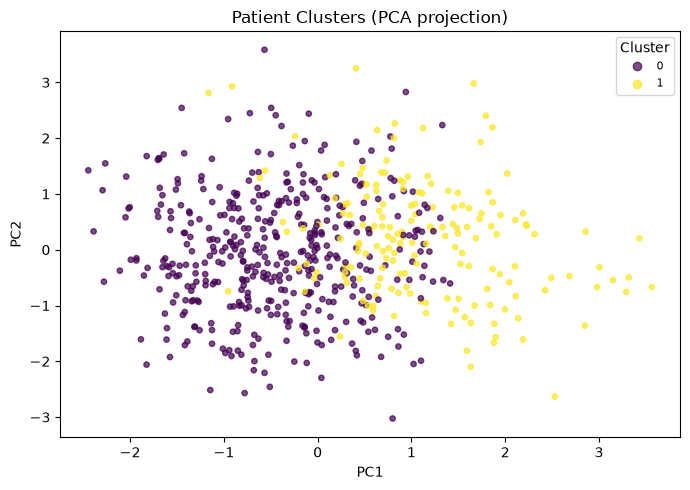

In [48]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_ids, cmap="viridis", s=15, alpha=0.7)
plt.title("Patient Clusters (PCA projection)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
plt.tight_layout()
plt.show()


## 7. Train MLP Classifier on Pseudo-Labels

In [49]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(risk_labels_arr)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.25, random_state=RANDOM_STATE, stratify=y_encoded
)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp_model.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)

y_test_names = label_encoder.inverse_transform(y_test)
y_pred_names = label_encoder.inverse_transform(y_pred)

acc = accuracy_score(y_test_names, y_pred_names)
print(f"MLP test accuracy: {acc:.3f}\n")
print(classification_report(y_test_names, y_pred_names))


MLP test accuracy: 0.980

               precision    recall  f1-score   support

     Low Risk       0.97      1.00      0.99       107
Moderate Risk       1.00      0.93      0.96        43

     accuracy                           0.98       150
    macro avg       0.99      0.97      0.98       150
 weighted avg       0.98      0.98      0.98       150



## 8. Confusion Matrix

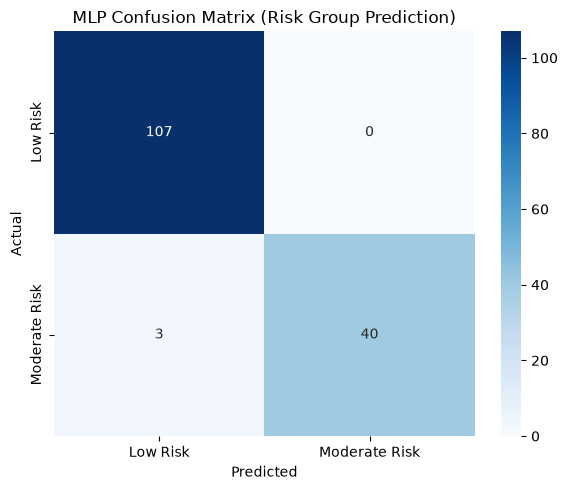

In [50]:
label_names = sorted(np.unique(risk_labels_arr), key=lambda x: RISK_ORDER.index(x) if x in RISK_ORDER else 99)
cm = confusion_matrix(y_test_names, y_pred_names, labels=label_names)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("MLP Confusion Matrix (Risk Group Prediction)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 9. Save Labeled Dataset
Writes the original data plus assigned `cluster_id` and `risk_group` columns to a CSV.

In [51]:
df_out = df_raw.copy()
df_out["cluster_id"] = cluster_ids
df_out["risk_group"] = risk_labels_arr
df_out.to_csv("patient_risk_results_labeled.csv", index=False)
df_out.head()


,age,bmi,blood_pressure,glucose,cholesterol,heart_rate,smoking,exercise,family_history,cluster_id,risk_group
0,54.570756,29.577052,101.194260,108.808812,182.157225,89.988272,0,0,1,0,Low Risk
1,34.400238,24.112306,116.248506,123.273638,239.207635,83.252306,0,1,0,0,Low Risk
2,61.256768,33.372236,132.564081,100.867197,211.246927,98.593530,1,0,1,1,Moderate Risk
3,64.108471,23.862062,123.156859,97.710532,172.097712,56.426006,0,1,0,0,Low Risk
4,20.734472,23.816924,113.289855,112.770621,165.362405,71.815679,0,1,1,0,Low Risk


## 10. Predict Risk Group for New Patients
Edit `new_patients` below with real records, then run to get predicted risk groups.

In [53]:
new_patients = pd.DataFrame([
    {"age": 62, "bmi": 31.5, "blood_pressure": 148, "glucose": 165,
     "cholesterol": 245, "heart_rate": 88, "smoking": 1, "exercise": 0, "family_history": 1},
    {"age": 28, "bmi": 22.0, "blood_pressure": 112, "glucose": 90,
     "cholesterol": 170, "heart_rate": 68, "smoking": 0, "exercise": 1, "family_history": 0},
])

new_scaled = scaler.transform(new_patients[FEATURES])
new_pred_encoded = mlp_model.predict(new_scaled)
new_pred_labels = label_encoder.inverse_transform(new_pred_encoded)

new_patients["predicted_risk_group"] = new_pred_labels
new_patients


,age,bmi,blood_pressure,glucose,cholesterol,heart_rate,smoking,exercise,family_history,predicted_risk_group
0,62,31.5,148,165,245,88,1,0,1,Moderate Risk
1,28,22.0,112,90,170,68,0,1,0,Low Risk
